In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
data = pd.read_csv("C:/Users/hp/Desktop/Everything/Work/Projects/linear regression/data sets/turbine_5yr_complex_data.csv")
df = pd.DataFrame(data)

0.0001366827973654037 -0.5068348102729061


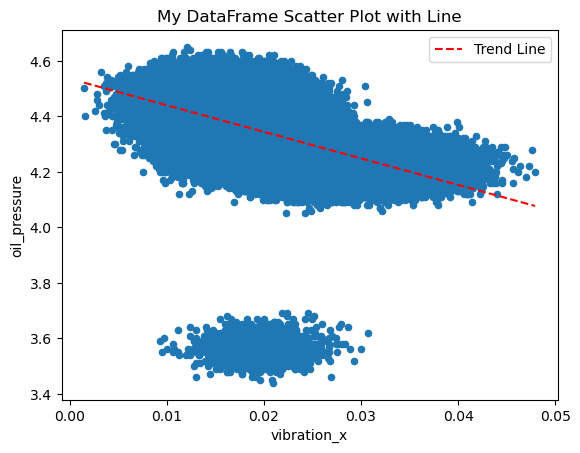

In [5]:
# using adam this is also not my code 

import numpy as np

x1 = df.iloc[:,3].values
y1 = df.iloc[:,6].values

# Normalize
x = (x - x.mean()) / x.std()
y = (y - y.mean()) / y.std()

# Initialize parameters
m1 = 0
m2 = 0

# Adam parameters
alpha = 0.01
beta1 = 0.9
beta2 = 0.999
epsilon = 1e-8

# Moment variables
m1_m = 0
m1_v = 0
m2_m = 0
m2_v = 0

t = 0
epochs = 100
batch_size = 320
n = len(x)

for epoch in range(epochs):
    
    indices = np.random.permutation(n)
    
    for start in range(0, n, batch_size):
        t += 1
        
        batch_idx = indices[start:start+batch_size]
        xb = x[batch_idx]
        yb = y[batch_idx]
        
        # Predictions
        y_pred = m2 * xb + m1
        error = yb - y_pred
        
        # Gradients
        g_m2 = (-2/len(xb)) * np.sum(xb * error)
        g_m1 = (-2/len(xb)) * np.sum(error)
        
        # Update first moment
        m2_m = beta1 * m2_m + (1 - beta1) * g_m2
        m1_m = beta1 * m1_m + (1 - beta1) * g_m1
        
        # Update second moment
        m2_v = beta2 * m2_v + (1 - beta2) * (g_m2**2)
        m1_v = beta2 * m1_v + (1 - beta2) * (g_m1**2)
        
        # Bias correction
        m2_m_hat = m2_m / (1 - beta1**t)
        m1_m_hat = m1_m / (1 - beta1**t)
        
        m2_v_hat = m2_v / (1 - beta2**t)
        m1_v_hat = m1_v / (1 - beta2**t)
        
        # Update parameters
        m2 = m2 - alpha * (m2_m_hat / (np.sqrt(m2_v_hat) + epsilon))
        m1 = m1 - alpha * (m1_m_hat / (np.sqrt(m1_v_hat) + epsilon))

print(m1, m2)

wori = m2 * (y1.std()/x1.std())
borig = y1.mean() - (wori * x1.mean())

ax = df.plot.scatter(x = 'vibration_x' , y ='oil_pressure')


x_vals = np.linspace(x1.min(), x1.max(), 100)
yvalues = (x_vals * wori) + borig


ax.plot(x_vals, yvalues, color='red', linestyle='--', label='Trend Line')

plt.title('My DataFrame Scatter Plot with Line')
plt.legend()
plt.show()
